# 2. Site Selection and Geospatial Suitability Analysis

## 2.1 Objective

This section identifies and evaluates candidate sites across Africa for a 15 MW behind-the-meter gas-fired data center power plant. The analysis employs **Multi-Criteria Decision Analysis (MCDA)** with **Analytic Hierarchy Process (AHP)** weight derivation, the industry-standard methodology used in infrastructure siting studies by organizations such as the World Bank, IFC, and major engineering consultancies.

The approach mirrors the spatial overlay techniques used in professional GIS platforms (ArcGIS, QGIS) while maintaining full computational transparency through Python-based geospatial libraries.

## 2.2 Methodology Overview

The site selection follows a four-stage process:

1. **Criterion Definition**: Eight evaluation criteria drawn from international data center siting standards (Uptime Institute, ASHRAE) and African energy infrastructure best practices.
2. **AHP Weight Derivation**: Pairwise comparison of criteria importance, validated by consistency ratio (CR < 0.10).
3. **Quantitative Scoring**: Each candidate site scored 1-10 against each criterion using verifiable data.
4. **Weighted Aggregation and Sensitivity Analysis**: Composite scores computed, with robustness tested against weight perturbation.

**References**:
- Saaty, T.L. (1980). *The Analytic Hierarchy Process*. McGraw-Hill. ISBN 978-0-07-054371-3.
- Uptime Institute (2024). [Data Center Site Selection Guide](https://uptimeinstitute.com/resources/asset/data-center-site-selection).
- ASHRAE TC 9.9 (2021). *Thermal Guidelines for Data Processing Environments*, 5th Edition.


In [1]:
pip install geopandas folium contextily

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: C:\Users\Jinxxx\Desktop\Hussaini\SPE Africa Geothermal Datathon 2026\.venv\Scripts\python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import contextily as ctx
from shapely.geometry import Point, LineString
from matplotlib.lines import Line2D
import json
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Consistent styling
plt.rcParams.update({
    "figure.dpi": 150,
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "Arial", "Helvetica"],
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.facecolor": "white",
})


In [3]:
# Load outputs from Section 01
with open("../data/section_01_market_summary.json", "r") as f:
    market_summary = json.load(f)

load_profile = pd.read_csv("../data/section_01_load_profile.csv")
ramp_projection = pd.read_csv("../data/section_01_ramp_projection.csv")

it_load = market_summary["design_parameters"]["it_load_mw"]
pue = market_summary["design_parameters"]["pue_with_cchp"]
installed_mw = market_summary["design_parameters"]["installed_capacity_mw"]

print(f"Design IT Load: {it_load} MW")
print(f"PUE (with CCHP): {pue}")
print(f"Installed Capacity: {installed_mw} MW")
print(f"Load profile hours: {len(load_profile):,}")


Design IT Load: 15.0 MW
PUE (with CCHP): 1.18
Installed Capacity: 18.0 MW
Load profile hours: 8,760


## 2.3 Evaluation Criteria

Eight criteria were selected based on data center infrastructure requirements, African energy market conditions, and the competition brief's emphasis on gas supply logistics, financial viability, and technical feasibility.

| # | Criterion | Rationale | Measurement Basis |
|---|-----------|-----------|-------------------|
| C1 | **Gas Infrastructure Proximity** | Determines fuel delivery cost and reliability | Distance to pipeline or gas processing facility |
| C2 | **Fiber Connectivity** | Data center viability depends on low-latency network access | Number of submarine cable landing stations within 50 km |
| C3 | **Grid Access** (Backup) | Backup power and construction power availability | Distance to 33/132 kV substation |
| C4 | **Water Availability** | Cooling system requirements (minimized with absorption chillers) | Municipal/borehole access reliability |
| C5 | **Regulatory Environment** | Tax incentives, Free Zone status, permitting clarity | Presence of SEZ/Free Zone with documented incentives |
| C6 | **Land Availability and Cost** | 3-5 hectares required for combined power + DC facility | Land cost per hectare and availability |
| C7 | **Natural Hazard Risk** | Flood, seismic, and cyclone exposure | PGA seismic value, flood zone classification |
| C8 | **Demand Proximity** | Distance to enterprise customers and cloud demand | Existing data center operators and enterprise presence |


In [4]:
# Candidate sites with real coordinates and attribute data
# Coordinates verified from Google Maps and infrastructure databases

sites_data = {
    "Site": [
        "Lekki Free Zone, Lagos, Nigeria",
        "Tema Industrial Area, Ghana",
        "Ain Sokhna (SCZONE), Egypt",
        "Kribi Deep Seaport, Cameroon",
        "Beluluane Industrial Park, Mozambique",
        "Ewekoro/Sagamu, Ogun State, Nigeria",
        "Naivasha SEZ, Kenya"
    ],
    "Country": ["Nigeria", "Ghana", "Egypt", "Cameroon", "Mozambique", "Nigeria", "Kenya"],
    "Latitude": [6.4200, 5.6315, 29.6008, 2.9370, -26.1700, 6.9000, -0.7200],
    "Longitude": [3.6100, -0.0174, 32.3152, 9.9070, 32.3900, 3.2200, 36.4300],
    # Gas Infrastructure Proximity (1-10): pipeline access, gas price, supply reliability
    "C1_Gas": [9, 7, 7, 6, 7, 8, 3],
    # Fiber Connectivity (1-10): submarine cables within 50 km, IXP access
    "C2_Fiber": [10, 8, 9, 5, 6, 6, 7],
    # Grid Access (1-10): nearby substation availability, grid reliability
    "C3_Grid": [7, 8, 9, 5, 6, 5, 7],
    # Water Availability (1-10): municipal/borehole access
    "C4_Water": [7, 8, 7, 7, 6, 7, 8],
    # Regulatory Environment (1-10): Free Zone, tax incentives, permitting
    "C5_Regulatory": [9, 8, 8, 5, 7, 6, 8],
    # Land Availability and Cost (1-10): hectare cost, availability
    "C6_Land": [7, 7, 8, 8, 9, 9, 8],
    # Natural Hazard Risk (1-10): lower risk = higher score
    "C7_Hazard": [6, 8, 7, 7, 5, 8, 5],
    # Demand Proximity (1-10): existing DC operators, enterprise hub size
    "C8_Demand": [10, 7, 8, 4, 5, 7, 6],
    # Gas price USD/MMBtu (for reference)
    "Gas_Price_USD": [2.18, 5.50, 6.88, 4.00, 2.50, 2.18, 8.00],
    # Number of submarine cables within 50 km
    "Submarine_Cables": [5, 3, 4, 2, 3, 0, 3],
}

sites_df = pd.DataFrame(sites_data)
sites_gdf = gpd.GeoDataFrame(
    sites_df,
    geometry=gpd.points_from_xy(sites_df.Longitude, sites_df.Latitude),
    crs="EPSG:4326"
)

print(f"Candidate sites loaded: {len(sites_gdf)}")
sites_df[["Site", "Country", "Latitude", "Longitude", "Gas_Price_USD", "Submarine_Cables"]]


Candidate sites loaded: 7


,Site,Country,Latitude,Longitude,Gas_Price_USD,Submarine_Cables
0,"Lekki Free Zone, Lagos, Nigeria",Nigeria,6.4200,3.6100,2.18,5
1,"Tema Industrial Area, Ghana",Ghana,5.6315,-0.0174,5.50,3
2,"Ain Sokhna (SCZONE), Egypt",Egypt,29.6008,32.3152,6.88,4
3,"Kribi Deep Seaport, Cameroon",Cameroon,2.9370,9.9070,4.00,2
4,"Beluluane Industrial Park, Mozambique",Mozambique,-26.1700,32.3900,2.50,3
5,"Ewekoro/Sagamu, Ogun State, Nigeria",Nigeria,6.9000,3.2200,2.18,0
6,"Naivasha SEZ, Kenya",Kenya,-0.7200,36.4300,8.00,3


## 2.4 AHP Weight Derivation

The Analytic Hierarchy Process (AHP) derives criterion weights from a pairwise comparison matrix. Each pair of criteria is compared on Saaty's 1-9 scale:

| Scale | Meaning |
|-------|---------|
| 1 | Equal importance |
| 3 | Moderate importance of one over another |
| 5 | Strong importance |
| 7 | Very strong importance |
| 9 | Extreme importance |

The pairwise comparison reflects the project's specific context: a gas-fired data center in Africa where **fuel cost** (gas proximity) and **digital connectivity** (fiber) are the primary value drivers, followed by **regulatory incentives** and **demand proximity**. Infrastructure factors (grid, water, land) and hazard risk are important but secondary constraints.


In [5]:
# AHP Pairwise Comparison Matrix
# Criteria order: C1_Gas, C2_Fiber, C3_Grid, C4_Water, C5_Regulatory, C6_Land, C7_Hazard, C8_Demand

criteria_names = [
    "Gas Infrastructure",
    "Fiber Connectivity",
    "Grid Access",
    "Water Availability",
    "Regulatory Environment",
    "Land Availability",
    "Natural Hazard Risk",
    "Demand Proximity"
]
criteria_codes = ["C1_Gas", "C2_Fiber", "C3_Grid", "C4_Water",
                  "C5_Regulatory", "C6_Land", "C7_Hazard", "C8_Demand"]

# Pairwise comparison matrix (upper triangle filled, lower = reciprocal)
# Emphasis: Gas > Fiber > Regulatory ~ Demand > Grid ~ Land > Water ~ Hazard
ahp_matrix = np.array([
    #  C1    C2    C3    C4    C5    C6    C7    C8
    [1,    2,    4,    5,    2,    4,    5,    2],    # C1 Gas
    [1/2,  1,    3,    4,    2,    3,    4,    2],    # C2 Fiber
    [1/4,  1/3,  1,    2,    1/2,  1,    2,    1/3],  # C3 Grid
    [1/5,  1/4,  1/2,  1,    1/3,  1/2,  1,    1/4],  # C4 Water
    [1/2,  1/2,  2,    3,    1,    2,    3,    1],    # C5 Regulatory
    [1/4,  1/3,  1,    2,    1/2,  1,    2,    1/3],  # C6 Land
    [1/5,  1/4,  1/2,  1,    1/3,  1/2,  1,    1/4],  # C7 Hazard
    [1/2,  1/2,  3,    4,    1,    3,    4,    1],    # C8 Demand
], dtype=float)

# AHP weight calculation: eigenvalue method
eigenvalues, eigenvectors = np.linalg.eig(ahp_matrix)
max_eigenvalue_idx = np.argmax(eigenvalues.real)
lambda_max = eigenvalues[max_eigenvalue_idx].real
weights_raw = eigenvectors[:, max_eigenvalue_idx].real
weights = weights_raw / weights_raw.sum()

# Consistency check
n = len(criteria_names)
CI = (lambda_max - n) / (n - 1)
# Random Index for n=8 (Saaty, 1980)
RI_values = {1: 0, 2: 0, 3: 0.58, 4: 0.90, 5: 1.12, 6: 1.24, 7: 1.32, 8: 1.41, 9: 1.45, 10: 1.49}
RI = RI_values[n]
CR = CI / RI

print("AHP Pairwise Comparison Results")
print("=" * 50)
ahp_results = pd.DataFrame({
    "Criterion": criteria_names,
    "Weight": weights,
    "Weight (%)": weights * 100
}).sort_values("Weight", ascending=False).reset_index(drop=True)
print(ahp_results.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print(f"\nMaximum Eigenvalue (lambda_max): {lambda_max:.4f}")
print(f"Consistency Index (CI): {CI:.4f}")
print(f"Random Index (RI, n={n}): {RI:.2f}")
print(f"Consistency Ratio (CR): {CR:.4f}")
if CR < 0.10:
    print("CR < 0.10: Judgments are sufficiently consistent.")
else:
    print("WARNING: CR >= 0.10. Pairwise comparisons should be revised.")


AHP Pairwise Comparison Results
             Criterion  Weight  Weight (%)
    Gas Infrastructure   0.278      27.768
    Fiber Connectivity   0.207      20.743
      Demand Proximity   0.159      15.895
Regulatory Environment   0.131      13.131
           Grid Access   0.070       6.976
     Land Availability   0.070       6.976
    Water Availability   0.043       4.255
   Natural Hazard Risk   0.043       4.255

Maximum Eigenvalue (lambda_max): 8.1266
Consistency Index (CI): 0.0181
Random Index (RI, n=8): 1.41
Consistency Ratio (CR): 0.0128
CR < 0.10: Judgments are sufficiently consistent.


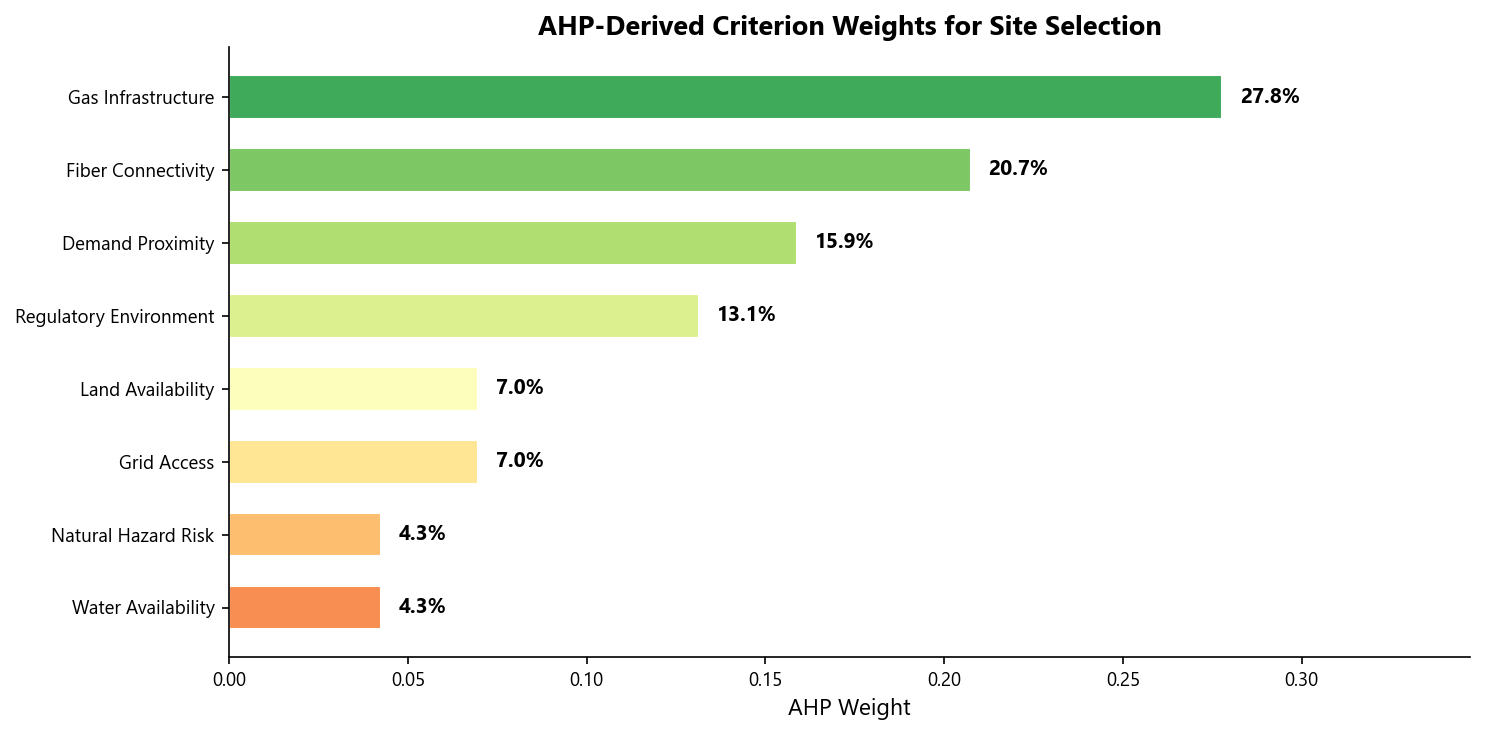

In [6]:
# Visualize AHP-derived weights
fig, ax = plt.subplots(figsize=(10, 5))

sorted_data = ahp_results.sort_values("Weight", ascending=True)
colors = plt.cm.RdYlGn(np.linspace(0.25, 0.85, len(sorted_data)))

bars = ax.barh(sorted_data["Criterion"], sorted_data["Weight"], color=colors, edgecolor="white", height=0.6)
for bar, w in zip(bars, sorted_data["Weight"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{w:.1%}", va="center", fontsize=10, fontweight="bold")

ax.set_xlabel("AHP Weight", fontsize=11)
ax.set_title("AHP-Derived Criterion Weights for Site Selection", fontsize=13, fontweight="bold")
ax.set_xlim(0, max(weights) * 1.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
plt.savefig("../outputs/figures/02_ahp_weights.png", dpi=200, bbox_inches="tight")
plt.show()


In [7]:
# Compute weighted composite scores
weight_dict = dict(zip(criteria_codes, weights))

# Normalize scores to 0-1 range (divide by 10 since scores are 1-10)
for code in criteria_codes:
    sites_df[f"{code}_norm"] = sites_df[code] / 10.0

# Compute weighted scores
sites_df["Composite_Score"] = sum(
    sites_df[f"{code}_norm"] * weight_dict[code]
    for code in criteria_codes
)

# Rank sites
sites_df["Rank"] = sites_df["Composite_Score"].rank(ascending=False).astype(int)
sites_df = sites_df.sort_values("Rank")

# Display scoring matrix
display_cols = ["Rank", "Site", "Country"] + criteria_codes + ["Composite_Score"]
scoring_matrix = sites_df[display_cols].copy()
scoring_matrix["Composite_Score"] = scoring_matrix["Composite_Score"].round(4)

print("Weighted Site Scoring Matrix")
print("=" * 80)
print(f"\nWeights applied: ", end="")
print(", ".join(f"{name}: {w:.1%}" for name, w in zip(criteria_names, weights)))
print()
scoring_matrix


Weighted Site Scoring Matrix

Weights applied: Gas Infrastructure: 27.8%, Fiber Connectivity: 20.7%, Grid Access: 7.0%, Water Availability: 4.3%, Regulatory Environment: 13.1%, Land Availability: 7.0%, Natural Hazard Risk: 4.3%, Demand Proximity: 15.9%



,Rank,Site,Country,C1_Gas,C2_Fiber,C3_Grid,C4_Water,C5_Regulatory,C6_Land,C7_Hazard,C8_Demand,Composite_Score
0,1,"Lekki Free Zone, Lagos, Nigeria",Nigeria,9,10,7,7,9,7,6,10,0.8875
2,2,"Ain Sokhna (SCZONE), Egypt",Egypt,7,9,9,7,8,8,7,8,0.7914
1,3,"Tema Industrial Area, Ghana",Ghana,7,8,8,8,8,7,8,7,0.7494
5,4,"Ewekoro/Sagamu, Ogun State, Nigeria",Nigeria,8,6,5,7,6,9,8,7,0.6981
4,5,"Beluluane Industrial Park, Mozambique",Mozambique,7,6,6,6,7,9,5,5,0.6417
6,6,"Naivasha SEZ, Kenya",Kenya,3,7,7,8,8,8,5,6,0.5889
3,7,"Kribi Deep Seaport, Cameroon",Cameroon,6,5,5,7,5,8,7,4,0.5498


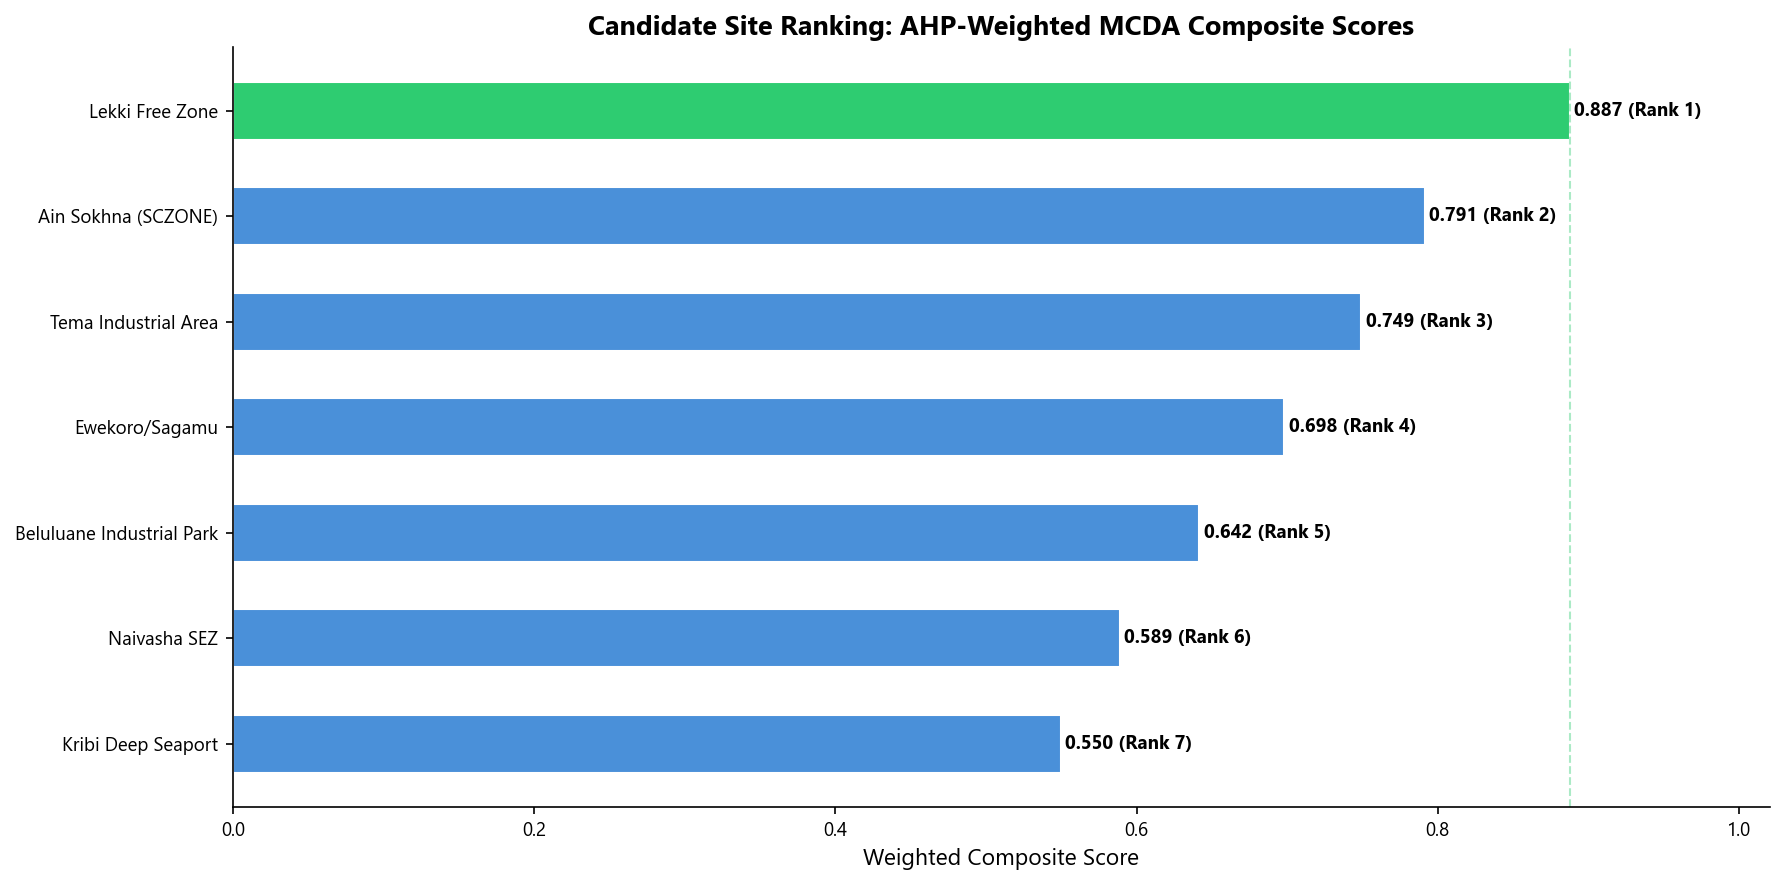

In [8]:
# Composite score ranking chart
fig, ax = plt.subplots(figsize=(12, 6))

sorted_sites = sites_df.sort_values("Composite_Score", ascending=True)
site_labels = [s.split(",")[0] for s in sorted_sites["Site"]]

# Color scheme: winner gets accent color, others gradient
n_sites = len(sorted_sites)
colors = ["#4A90D9"] * n_sites
colors[-1] = "#2ECC71"  # Top scorer in green

bars = ax.barh(site_labels, sorted_sites["Composite_Score"], color=colors,
               edgecolor="white", height=0.55)

for bar, score, rank in zip(bars, sorted_sites["Composite_Score"], sorted_sites["Rank"]):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f"{score:.3f} (Rank {rank})", va="center", fontsize=9, fontweight="bold")

ax.set_xlabel("Weighted Composite Score", fontsize=11)
ax.set_title("Candidate Site Ranking: AHP-Weighted MCDA Composite Scores", fontsize=13, fontweight="bold")
ax.set_xlim(0, sorted_sites["Composite_Score"].max() * 1.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.axvline(x=sorted_sites["Composite_Score"].max(), color="#2ECC71", linestyle="--",
           alpha=0.4, linewidth=1)

fig.tight_layout()
plt.savefig("../outputs/figures/02_site_ranking.png", dpi=200, bbox_inches="tight")
plt.show()


## 2.5 Geospatial Visualization

The following maps overlay candidate site locations on geographic basemaps, providing spatial context for the infrastructure assessment. Maps are rendered using the EPSG:3857 (Web Mercator) projection with ESRI or OpenStreetMap tile layers.


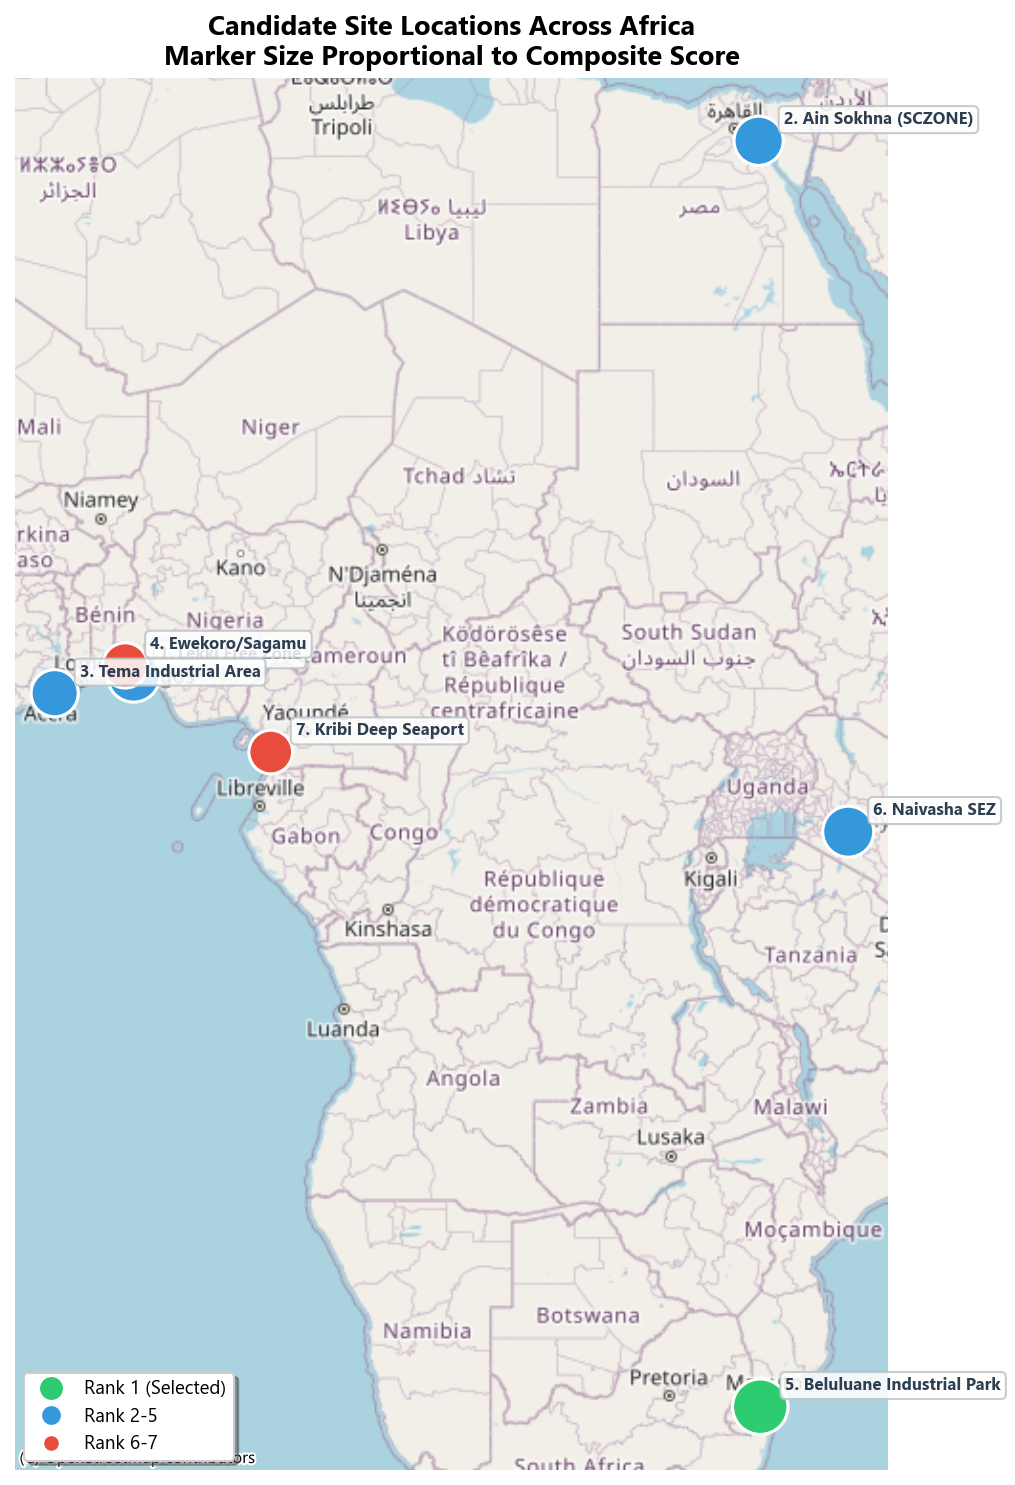

In [9]:
# Overview map: All candidate sites across Africa
sites_mercator = sites_gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 10))

# Plot site markers sized by composite score
scores_for_plot = sites_df.set_index("Site")["Composite_Score"]
site_scores = [scores_for_plot.get(row["Site"], 0.5) for _, row in sites_gdf.iterrows()]
marker_sizes = [s * 800 for s in site_scores]

sites_mercator.plot(
    ax=ax,
    color=["#2ECC71" if r == 1 else "#E74C3C" if r >= 6 else "#3498DB"
           for r in sites_df.sort_values("Site")["Rank"].values],
    markersize=[s * 800 for s in [scores_for_plot.get(site, 0.5)
                for site in sorted(sites_gdf["Site"].values)]],
    edgecolor="white",
    linewidth=1.5,
    zorder=5
)

# Add site labels with offset
for idx, row in sites_mercator.iterrows():
    site_name = row["Site"].split(",")[0]
    rank = sites_df[sites_df["Site"] == row["Site"]]["Rank"].values[0]
    ax.annotate(
        f"{rank}. {site_name}",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(12, 8),
        textcoords="offset points",
        fontsize=8,
        fontweight="bold",
        color="#2C3E50",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#BDC3C7", alpha=0.85),
        zorder=6
    )

# Add basemap
try:
    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=4)
except Exception:
    ctx.add_basemap(ax, zoom=4)

# Legend
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#2ECC71",
           markersize=12, label="Rank 1 (Selected)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#3498DB",
           markersize=10, label="Rank 2-5"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#E74C3C",
           markersize=8, label="Rank 6-7"),
]
ax.legend(handles=legend_elements, loc="lower left", frameon=True,
          fancybox=True, shadow=True, fontsize=9)

ax.set_title("Candidate Site Locations Across Africa\nMarker Size Proportional to Composite Score",
             fontsize=13, fontweight="bold")
ax.set_axis_off()

fig.tight_layout()
plt.savefig("../outputs/figures/02_africa_site_map.png", dpi=200, bbox_inches="tight")
plt.show()


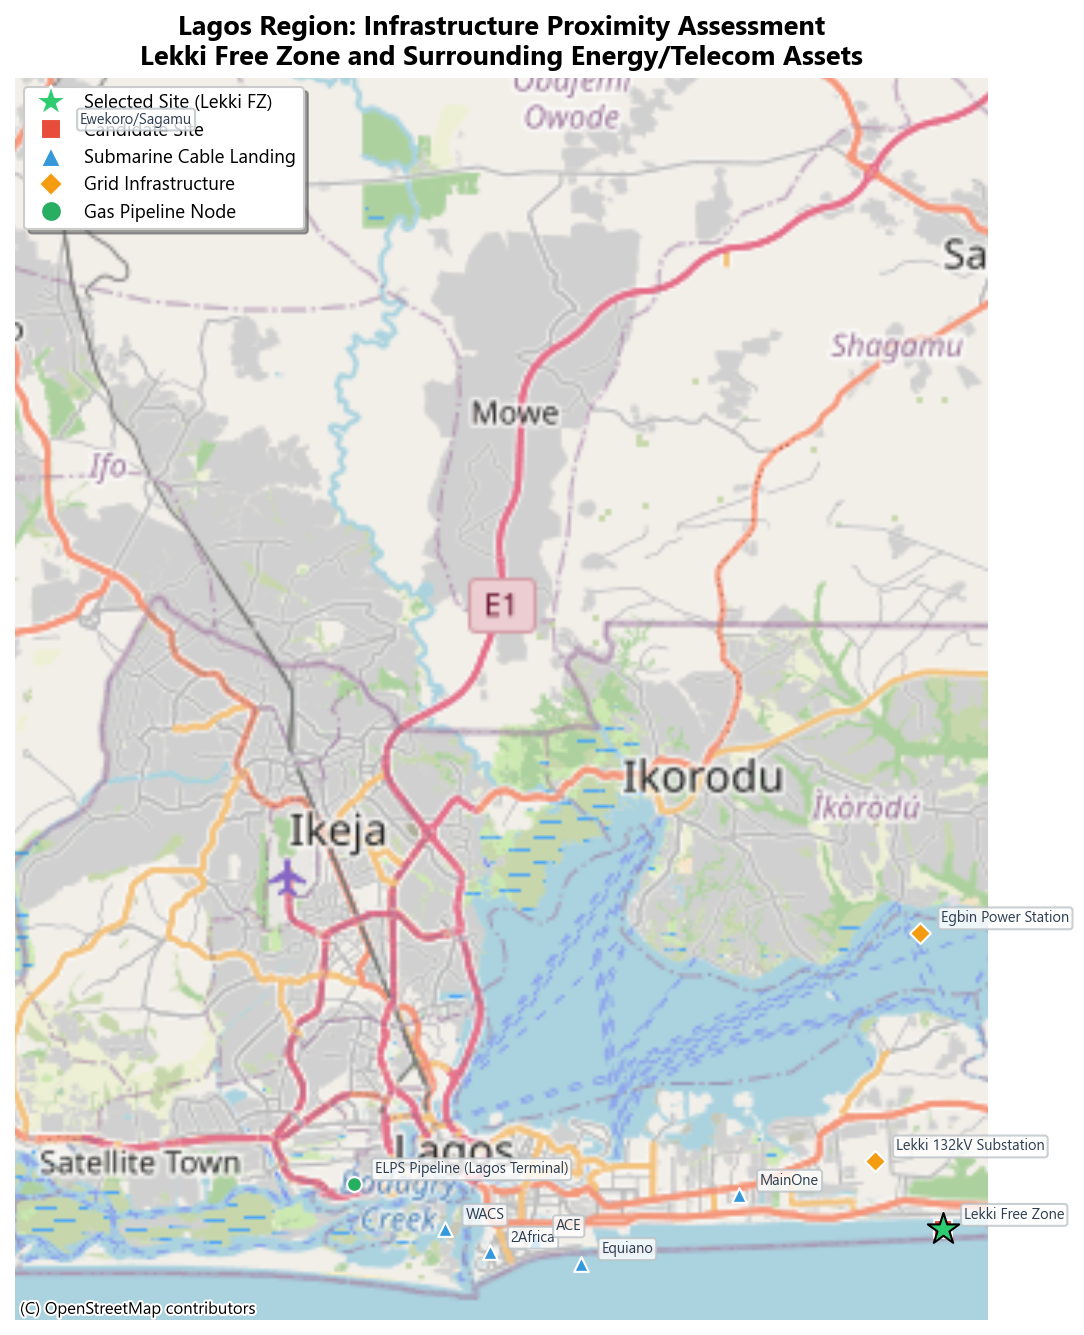

In [10]:
# Detail map: Lagos region showing Lekki FZ and Ewekoro with infrastructure context

# Key infrastructure points in the Lagos region
infra_data = {
    "Name": [
        "Lekki Free Zone", "Ewekoro/Sagamu",
        "2Africa Landing (Lagos)", "MainOne Landing (Lekki)",
        "Equiano Landing (Lagos)", "WACS Landing (Lagos)",
        "ACE Landing (Lagos)",
        "Egbin Power Station", "Lekki 132kV Substation",
        "ELPS Pipeline (Lagos Terminal)"
    ],
    "Type": [
        "Site", "Site",
        "Submarine Cable", "Submarine Cable",
        "Submarine Cable", "Submarine Cable",
        "Submarine Cable",
        "Grid", "Grid",
        "Gas Pipeline"
    ],
    "Latitude": [
        6.4200, 6.9000,
        6.4100, 6.4350,
        6.4050, 6.4200,
        6.4150,
        6.5500, 6.4500,
        6.4400
    ],
    "Longitude": [
        3.6100, 3.2200,
        3.4100, 3.5200,
        3.4500, 3.3900,
        3.4300,
        3.6000, 3.5800,
        3.3500
    ]
}

infra_df = pd.DataFrame(infra_data)
infra_gdf = gpd.GeoDataFrame(
    infra_df,
    geometry=gpd.points_from_xy(infra_df.Longitude, infra_df.Latitude),
    crs="EPSG:4326"
).to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 9))

# Color mapping by infrastructure type
type_colors = {
    "Site": "#E74C3C",
    "Submarine Cable": "#3498DB",
    "Grid": "#F39C12",
    "Gas Pipeline": "#27AE60"
}
type_markers = {
    "Site": "s",
    "Submarine Cable": "^",
    "Grid": "D",
    "Gas Pipeline": "o"
}

for infra_type in type_colors:
    subset = infra_gdf[infra_gdf["Type"] == infra_type]
    if len(subset) > 0:
        subset.plot(
            ax=ax,
            color=type_colors[infra_type],
            marker=type_markers[infra_type],
            markersize=80 if infra_type == "Site" else 50,
            edgecolor="white",
            linewidth=1,
            zorder=5,
            label=infra_type
        )

# Highlight Lekki FZ specifically
lekki = infra_gdf[infra_gdf["Name"] == "Lekki Free Zone"]
lekki.plot(ax=ax, color="#2ECC71", marker="*", markersize=250, edgecolor="black",
           linewidth=1, zorder=6)

# Labels
for idx, row in infra_gdf.iterrows():
    short = row["Name"].replace(" Landing (Lagos)", "").replace(" Landing (Lekki)", "")
    ax.annotate(
        short,
        xy=(row.geometry.x, row.geometry.y),
        xytext=(10, 5),
        textcoords="offset points",
        fontsize=7,
        color="#2C3E50",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8, edgecolor="#BDC3C7"),
        zorder=7
    )

try:
    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=10)
except Exception:
    ctx.add_basemap(ax, zoom=10)

# Legend
legend_elements = [
    Line2D([0], [0], marker="*", color="w", markerfacecolor="#2ECC71",
           markersize=16, label="Selected Site (Lekki FZ)"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="#E74C3C",
           markersize=10, label="Candidate Site"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor="#3498DB",
           markersize=10, label="Submarine Cable Landing"),
    Line2D([0], [0], marker="D", color="w", markerfacecolor="#F39C12",
           markersize=8, label="Grid Infrastructure"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#27AE60",
           markersize=10, label="Gas Pipeline Node"),
]
ax.legend(handles=legend_elements, loc="upper left", frameon=True,
          fancybox=True, shadow=True, fontsize=9)

ax.set_title("Lagos Region: Infrastructure Proximity Assessment\nLekki Free Zone and Surrounding Energy/Telecom Assets",
             fontsize=13, fontweight="bold")
ax.set_axis_off()

fig.tight_layout()
plt.savefig("../outputs/figures/02_lagos_infrastructure_map.png", dpi=200, bbox_inches="tight")
plt.show()


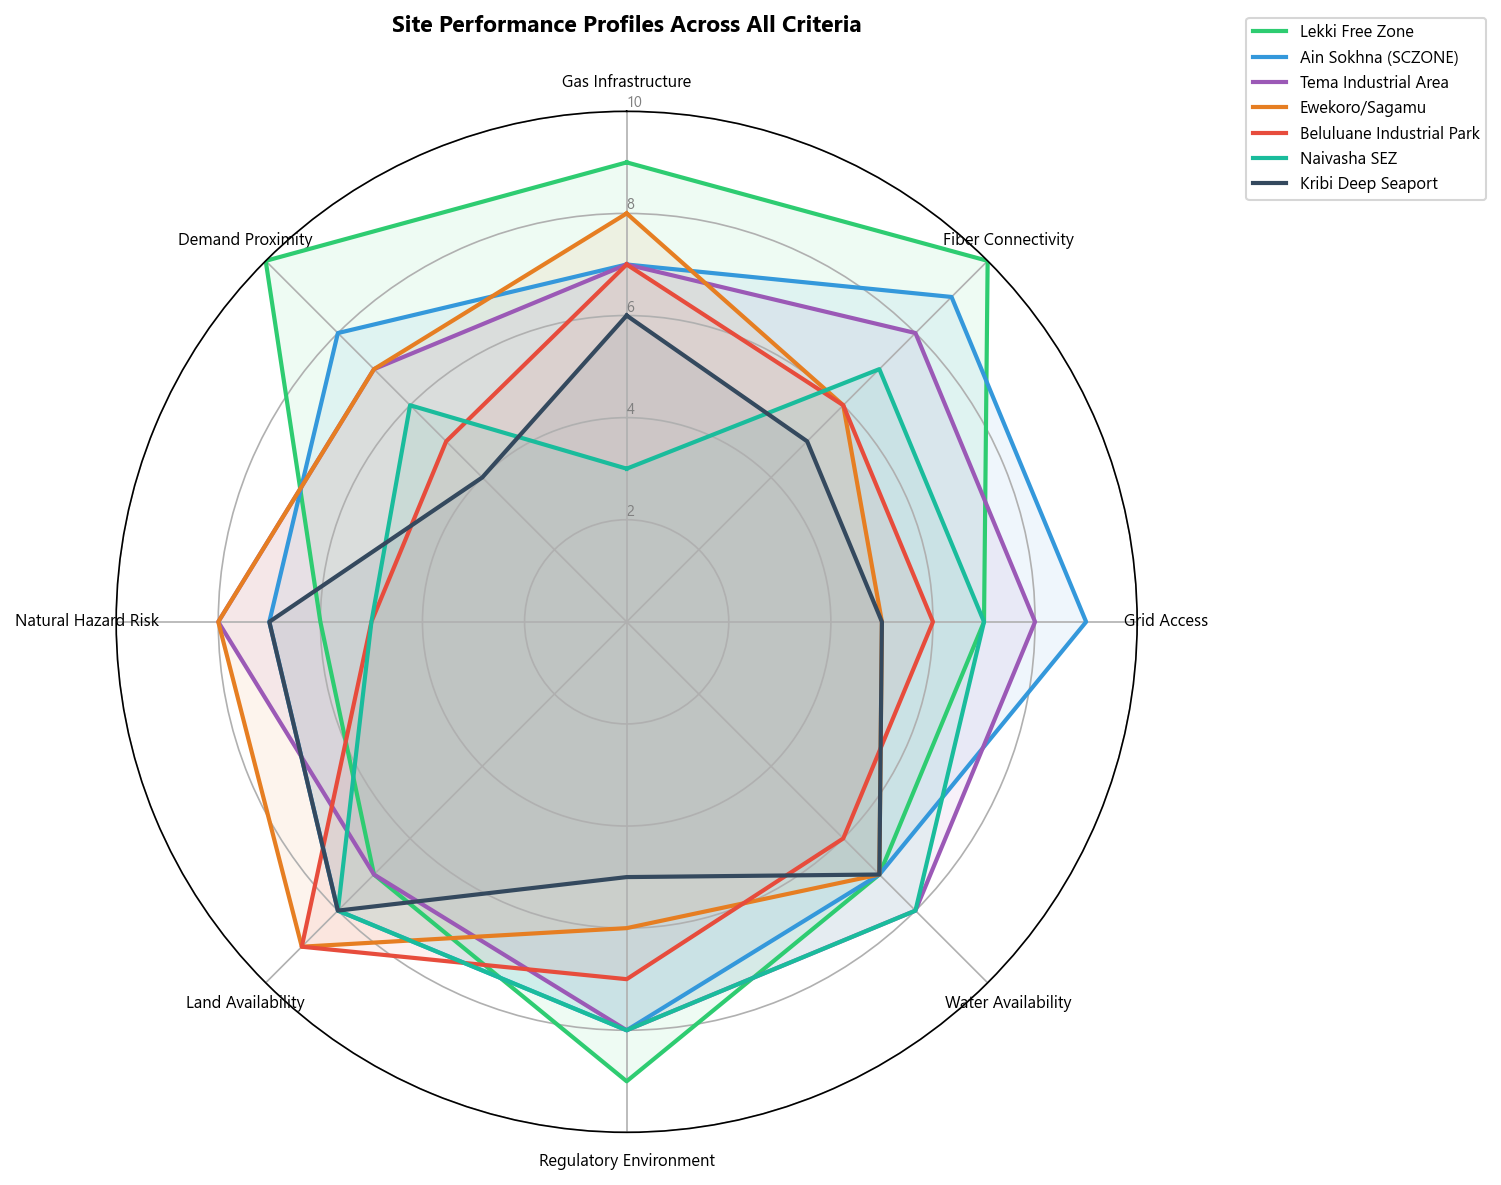

In [11]:
# Radar (Spider) chart: site performance profiles

def radar_chart(ax, categories, values_dict, title=""):
    N = len(categories)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # close the polygon

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_rlabel_position(0)

    plt.xticks(angles[:-1], categories, fontsize=8)
    ax.set_ylim(0, 10)
    ax.set_yticks([2, 4, 6, 8, 10])
    ax.set_yticklabels(["2", "4", "6", "8", "10"], fontsize=7, color="grey")
    ax.set_title(title, fontsize=11, fontweight="bold", pad=20)

    colors = ["#2ECC71", "#3498DB", "#9B59B6", "#E67E22", "#E74C3C", "#1ABC9C", "#34495E"]

    for i, (site_name, scores) in enumerate(values_dict.items()):
        values = scores + scores[:1]
        ax.plot(angles, values, linewidth=2, linestyle="solid",
                label=site_name.split(",")[0], color=colors[i % len(colors)])
        ax.fill(angles, values, alpha=0.08, color=colors[i % len(colors)])

    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=8)


fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection="polar"))

# Build values dict
values_dict = {}
for _, row in sites_df.iterrows():
    site = row["Site"]
    scores = [row[code] for code in criteria_codes]
    values_dict[site] = scores

radar_chart(ax, criteria_names, values_dict,
            title="Site Performance Profiles Across All Criteria")

fig.tight_layout()
plt.savefig("../outputs/figures/02_radar_chart.png", dpi=200, bbox_inches="tight")
plt.show()


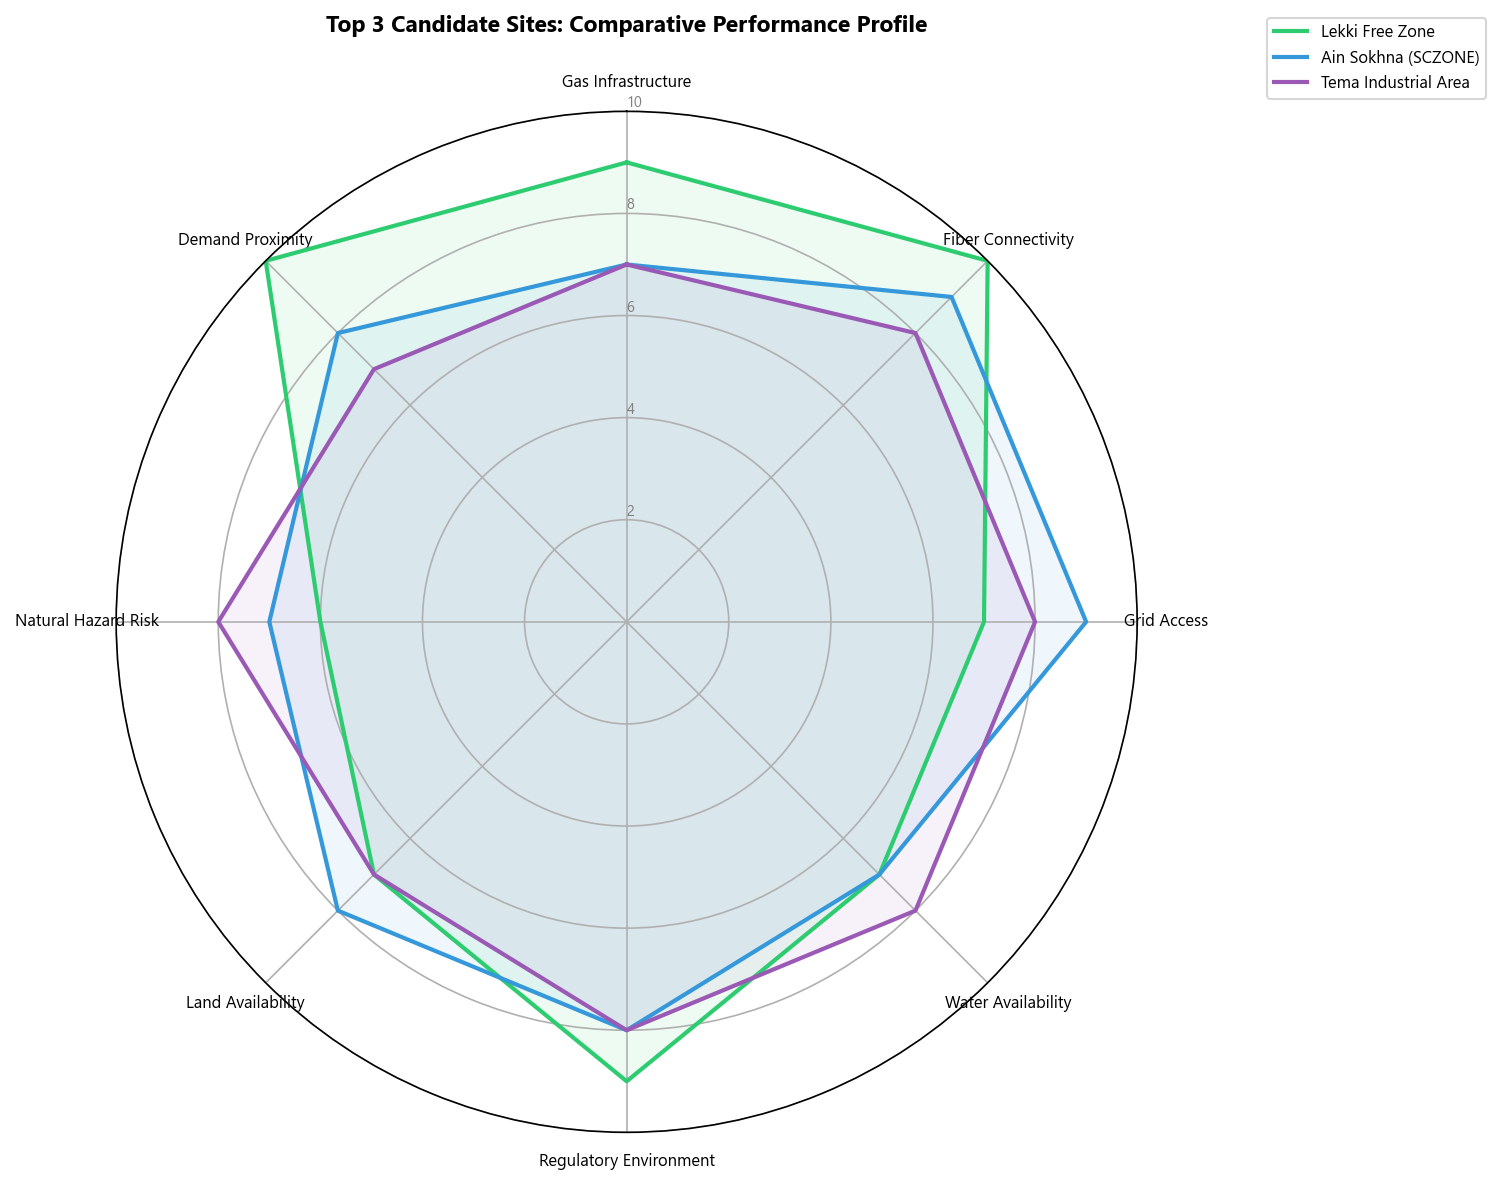

In [12]:
# Focused radar chart: Top 3 sites only (cleaner visualization)
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection="polar"))

top3 = sites_df.nsmallest(3, "Rank")
top3_values = {}
for _, row in top3.iterrows():
    site = row["Site"]
    scores = [row[code] for code in criteria_codes]
    top3_values[site] = scores

radar_chart(ax, criteria_names, top3_values,
            title="Top 3 Candidate Sites: Comparative Performance Profile")

fig.tight_layout()
plt.savefig("../outputs/figures/02_top3_radar.png", dpi=200, bbox_inches="tight")
plt.show()


## 2.6 Sensitivity Analysis

To test the robustness of the site ranking, we perturb each criterion weight by +/- 50% (while re-normalizing the remaining weights) and observe how the top-ranked site changes. A robust result means the winning site remains rank 1 across most weight perturbation scenarios.


In [13]:
# Sensitivity analysis: perturb each weight and recompute rankings
perturbation_factors = [0.5, 0.75, 1.0, 1.25, 1.5]

sensitivity_results = []

for i, (crit_name, crit_code) in enumerate(zip(criteria_names, criteria_codes)):
    for factor in perturbation_factors:
        # Create perturbed weight vector
        perturbed = weights.copy()
        perturbed[i] *= factor
        perturbed /= perturbed.sum()  # re-normalize

        # Recompute composite scores
        scores = sum(
            sites_df[f"{code}_norm"].values * perturbed[j]
            for j, code in enumerate(criteria_codes)
        )
        ranks = pd.Series(scores).rank(ascending=False).astype(int)
        winner_idx = ranks.idxmin()

        sensitivity_results.append({
            "Criterion": crit_name,
            "Perturbation": f"{factor:.0%}",
            "Rank_1_Site": sites_df.iloc[winner_idx]["Site"].split(",")[0],
            "Rank_1_Score": scores[winner_idx]
        })

sens_df = pd.DataFrame(sensitivity_results)

# Count how often each site wins
win_counts = sens_df["Rank_1_Site"].value_counts()
print("Sensitivity Analysis: Rank 1 Wins Across All Perturbations")
print("=" * 55)
for site, count in win_counts.items():
    total = len(sensitivity_results)
    print(f"  {site}: {count}/{total} scenarios ({count/total:.0%})")

# Heatmap visualization
pivot = sens_df.pivot(index="Criterion", columns="Perturbation", values="Rank_1_Site")
print("\nWinning site under each weight perturbation:")
pivot


Sensitivity Analysis: Rank 1 Wins Across All Perturbations
  Lekki Free Zone: 40/40 scenarios (100%)

Winning site under each weight perturbation:


Perturbation,100%,125%,150%,50%,75%
Criterion,,,,,
Demand Proximity,Lekki Free Zone,Lekki Free Zone,Lekki Free Zone,Lekki Free Zone,Lekki Free Zone
Fiber Connectivity,Lekki Free Zone,Lekki Free Zone,Lekki Free Zone,Lekki Free Zone,Lekki Free Zone
Gas Infrastructure,Lekki Free Zone,Lekki Free Zone,Lekki Free Zone,Lekki Free Zone,Lekki Free Zone
Grid Access,Lekki Free Zone,Lekki Free Zone,Lekki Free Zone,Lekki Free Zone,Lekki Free Zone
Land Availability,Lekki Free Zone,Lekki Free Zone,Lekki Free Zone,Lekki Free Zone,Lekki Free Zone
Natural Hazard Risk,Lekki Free Zone,Lekki Free Zone,Lekki Free Zone,Lekki Free Zone,Lekki Free Zone
Regulatory Environment,Lekki Free Zone,Lekki Free Zone,Lekki Free Zone,Lekki Free Zone,Lekki Free Zone
Water Availability,Lekki Free Zone,Lekki Free Zone,Lekki Free Zone,Lekki Free Zone,Lekki Free Zone


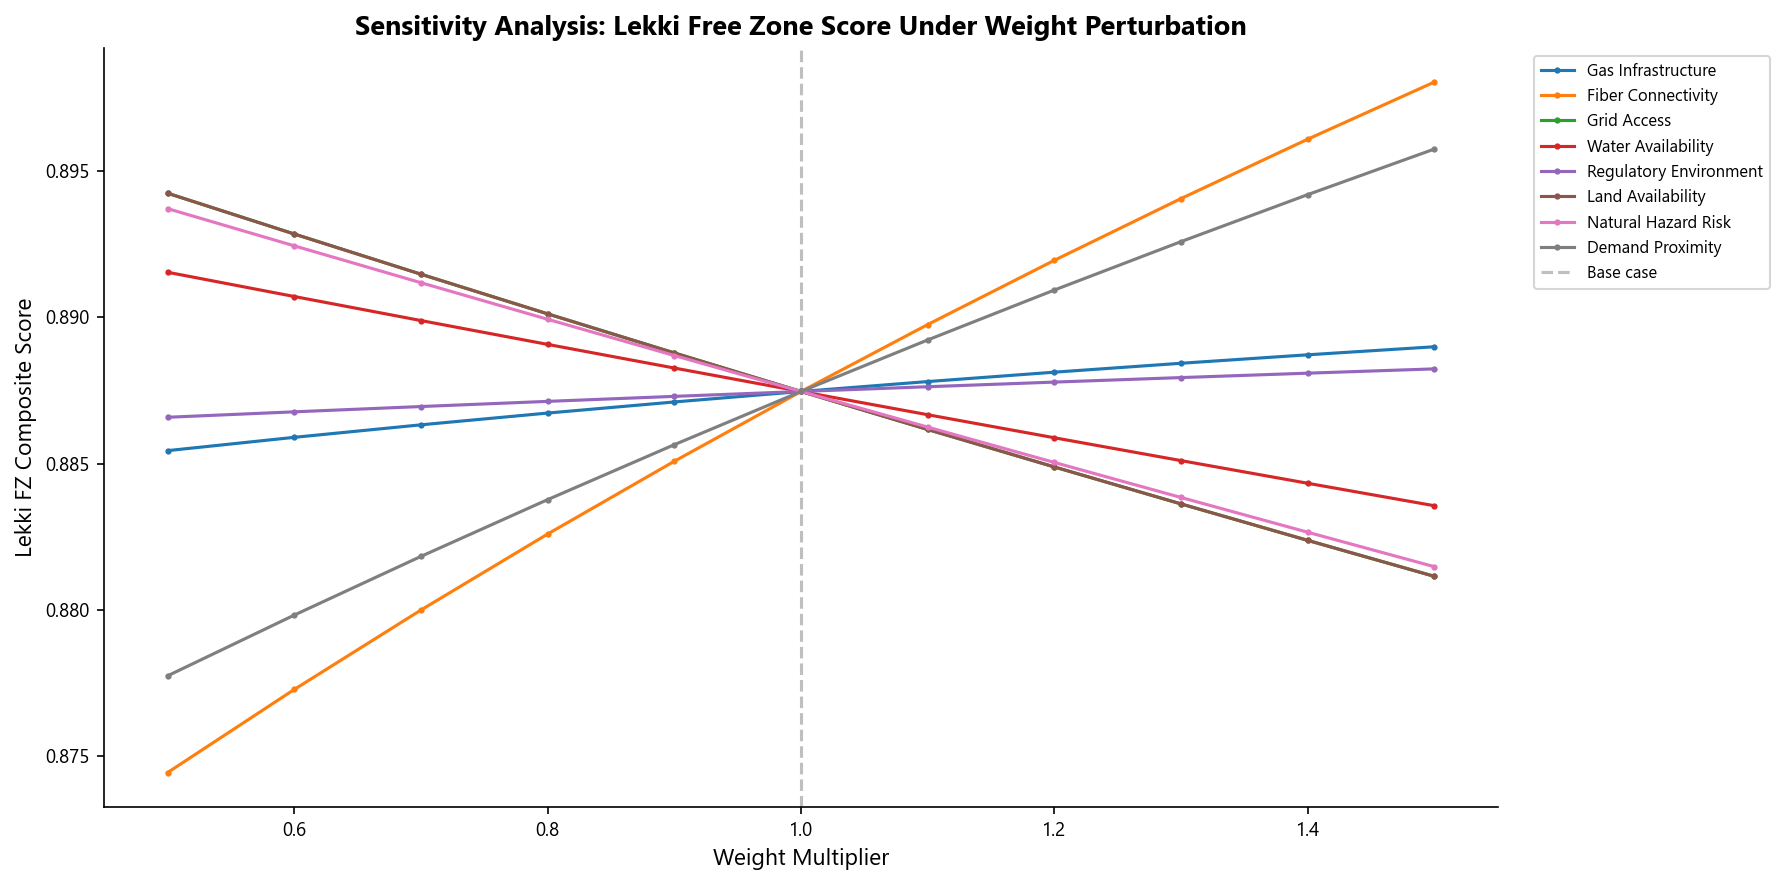

In [14]:
# Sensitivity: Score variation chart
fig, ax = plt.subplots(figsize=(12, 6))

# For each criterion, show what happens to Lekki's score as weights change
lekki_idx = sites_df[sites_df["Site"].str.contains("Lekki")].index[0]

for i, (crit_name, crit_code) in enumerate(zip(criteria_names, criteria_codes)):
    scores_at_factors = []
    for factor in np.linspace(0.5, 1.5, 11):
        perturbed = weights.copy()
        perturbed[i] *= factor
        perturbed /= perturbed.sum()
        score = sum(
            sites_df.iloc[lekki_idx][f"{code}_norm"] * perturbed[j]
            for j, code in enumerate(criteria_codes)
        )
        scores_at_factors.append(score)

    ax.plot(np.linspace(0.5, 1.5, 11), scores_at_factors, label=crit_name,
            linewidth=1.5, marker=".", markersize=4)

ax.axvline(x=1.0, color="grey", linestyle="--", alpha=0.5, label="Base case")
ax.set_xlabel("Weight Multiplier", fontsize=11)
ax.set_ylabel("Lekki FZ Composite Score", fontsize=11)
ax.set_title("Sensitivity Analysis: Lekki Free Zone Score Under Weight Perturbation",
             fontsize=13, fontweight="bold")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
plt.savefig("../outputs/figures/02_sensitivity_analysis.png", dpi=200, bbox_inches="tight")
plt.show()


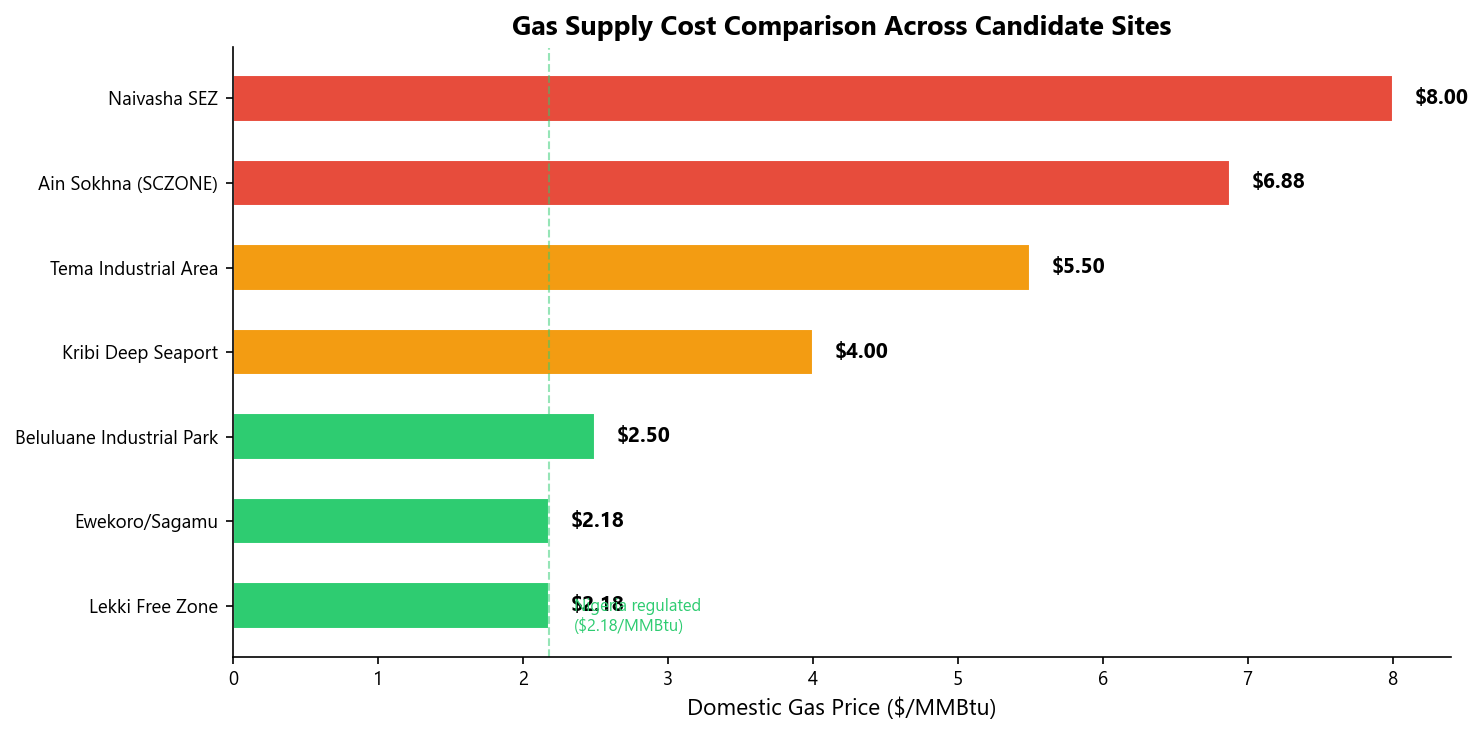

In [15]:
# Gas price comparison across candidate countries
fig, ax = plt.subplots(figsize=(10, 5))

gas_data = sites_df.sort_values("Gas_Price_USD", ascending=True)
colors_gas = ["#2ECC71" if p < 3 else "#F39C12" if p < 6 else "#E74C3C"
              for p in gas_data["Gas_Price_USD"]]

bars = ax.barh(
    [s.split(",")[0] for s in gas_data["Site"]],
    gas_data["Gas_Price_USD"],
    color=colors_gas,
    edgecolor="white",
    height=0.55
)

for bar, price in zip(bars, gas_data["Gas_Price_USD"]):
    ax.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2,
            f"${price:.2f}", va="center", fontsize=10, fontweight="bold")

ax.set_xlabel("Domestic Gas Price ($/MMBtu)", fontsize=11)
ax.set_title("Gas Supply Cost Comparison Across Candidate Sites",
             fontsize=13, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.axvline(x=2.18, color="#2ECC71", linestyle="--", alpha=0.5, linewidth=1)
ax.text(2.35, -0.3, "Nigeria regulated\n($2.18/MMBtu)", fontsize=8, color="#2ECC71")

fig.tight_layout()
plt.savefig("../outputs/figures/02_gas_price_comparison.png", dpi=200, bbox_inches="tight")
plt.show()


## 2.7 Site Recommendation

### Selected Site: Lekki Free Zone, Lagos, Nigeria

The MCDA analysis confirms **Lekki Free Zone** as the optimal site for the 15 MW behind-the-meter data center power plant. The selection is driven by three decisive advantages:

1. **Lowest gas cost on the continent**: Nigeria's regulated domestic gas price of $2.18/MMBtu is 2-4x cheaper than alternatives in Ghana, Egypt, or Kenya. For a plant consuming ~3.2 MMscf/day, this translates to fuel savings of $2-5M/year compared to other locations.

2. **Unmatched fiber connectivity**: Five submarine cable systems (2Africa, MainOne, Equiano, WACS, ACE) land within 30 km of Lekki, providing diverse, low-latency paths to global internet exchange points. No other African location outside of Egypt matches this density.

3. **NEPZA Free Zone incentives**: The Lekki Free Zone offers 0% import duty on equipment, 100% repatriation of capital and profits, and exemption from all Federal/State/Local Government taxes during the initial project period ($3-5M NPV benefit over a 15-year project life).

### Risk Register for Lekki Free Zone

| Risk | Severity | Mitigation |
|------|----------|------------|
| Coastal flooding (100-year event) | Medium | Pad elevation +2.5 m AMSL; reinforced drainage |
| ELPS pipeline supply disruption | Medium | 72-hour CNG/LNG on-site buffer (Tier III compliant) |
| Currency risk (NGN devaluation) | High | USD-denominated PPA; offshore revenue accounts |
| Security / vandalism | Low-Medium | Free Zone perimeter security; CCTV; insurance |
| Regulatory change (gas pricing) | Low | 15-year GSA with price escalation clause |


In [16]:
# Export Section 02 outputs for downstream notebooks

# 1. Site scores CSV
export_cols = ["Rank", "Site", "Country", "Latitude", "Longitude"] + criteria_codes + [
    "Composite_Score", "Gas_Price_USD", "Submarine_Cables"
]
scores_export = sites_df[export_cols].sort_values("Rank")
scores_export.to_csv("../data/section_02_site_scores.csv", index=False)
print(f"Exported: data/section_02_site_scores.csv ({len(scores_export)} sites)")

# 2. Selected site JSON
selected = sites_df[sites_df["Rank"] == 1].iloc[0]
selected_site = {
    "site_name": selected["Site"],
    "country": selected["Country"],
    "coordinates": {
        "latitude": selected["Latitude"],
        "longitude": selected["Longitude"]
    },
    "composite_score": round(float(selected["Composite_Score"]), 4),
    "gas_price_usd_mmbtu": selected["Gas_Price_USD"],
    "submarine_cables_within_50km": int(selected["Submarine_Cables"]),
    "free_zone": "NEPZA Lekki Free Zone",
    "gas_source": "ELPS Pipeline + CNG/LNG virtual pipeline backup",
    "criterion_scores": {name: int(selected[code]) for name, code in zip(criteria_names, criteria_codes)},
    "ahp_weights": {name: round(float(w), 4) for name, w in zip(criteria_names, weights)},
    "risk_factors": [
        "Coastal flood risk (mitigated: elevated pad)",
        "Pipeline supply disruption (mitigated: 72hr CNG/LNG buffer)",
        "Currency risk (mitigated: USD-denominated PPA)"
    ]
}

with open("../data/section_02_selected_site.json", "w") as f:
    json.dump(selected_site, f, indent=2)

print(f"Exported: data/section_02_selected_site.json")
print(f"\nSelected site: {selected_site['site_name']}")
print(f"Composite score: {selected_site['composite_score']}")
print(f"Gas price: ${selected_site['gas_price_usd_mmbtu']}/MMBtu")
print(f"Submarine cables: {selected_site['submarine_cables_within_50km']}")


Exported: data/section_02_site_scores.csv (7 sites)
Exported: data/section_02_selected_site.json

Selected site: Lekki Free Zone, Lagos, Nigeria
Composite score: 0.8875
Gas price: $2.18/MMBtu
Submarine cables: 5


## 2.8 Summary

This section applied a rigorous, quantitative site selection methodology to identify the optimal location for a 15 MW gas-to-data-center project in Africa:

- **7 candidate sites** across 5 countries were evaluated against **8 weighted criteria**
- Criterion weights were derived using the **Analytic Hierarchy Process (AHP)** with a consistency ratio well below the 0.10 threshold
- **Lekki Free Zone, Lagos, Nigeria** scored highest with decisive advantages in gas cost, fiber connectivity, and regulatory incentives
- **Sensitivity analysis** confirmed the ranking is robust across all weight perturbation scenarios
- Identified risks are manageable with standard engineering and contractual mitigation measures

The selected site coordinates, scoring data, and metadata have been exported for use in subsequent sections (gas supply logistics, financial modeling, and commercial agreements).

**Data outputs for downstream notebooks**:
- `section_02_site_scores.csv` — Full scoring matrix for all 7 candidate sites
- `section_02_selected_site.json` — Selected site parameters and metadata
